importing required libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge,Lasso,LinearRegression

importing dataset and doing data preprocessing

In [2]:
df = pd.read_csv("WineQT.csv")

In [3]:
df.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [5]:
df.nunique().count

<bound method Series.count of fixed acidity             91
volatile acidity         135
citric acid               77
residual sugar            80
chlorides                131
free sulfur dioxide       53
total sulfur dioxide     138
density                  388
pH                        87
sulphates                 89
alcohol                   61
quality                    6
Id                      1143
dtype: int64>

In [6]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [7]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


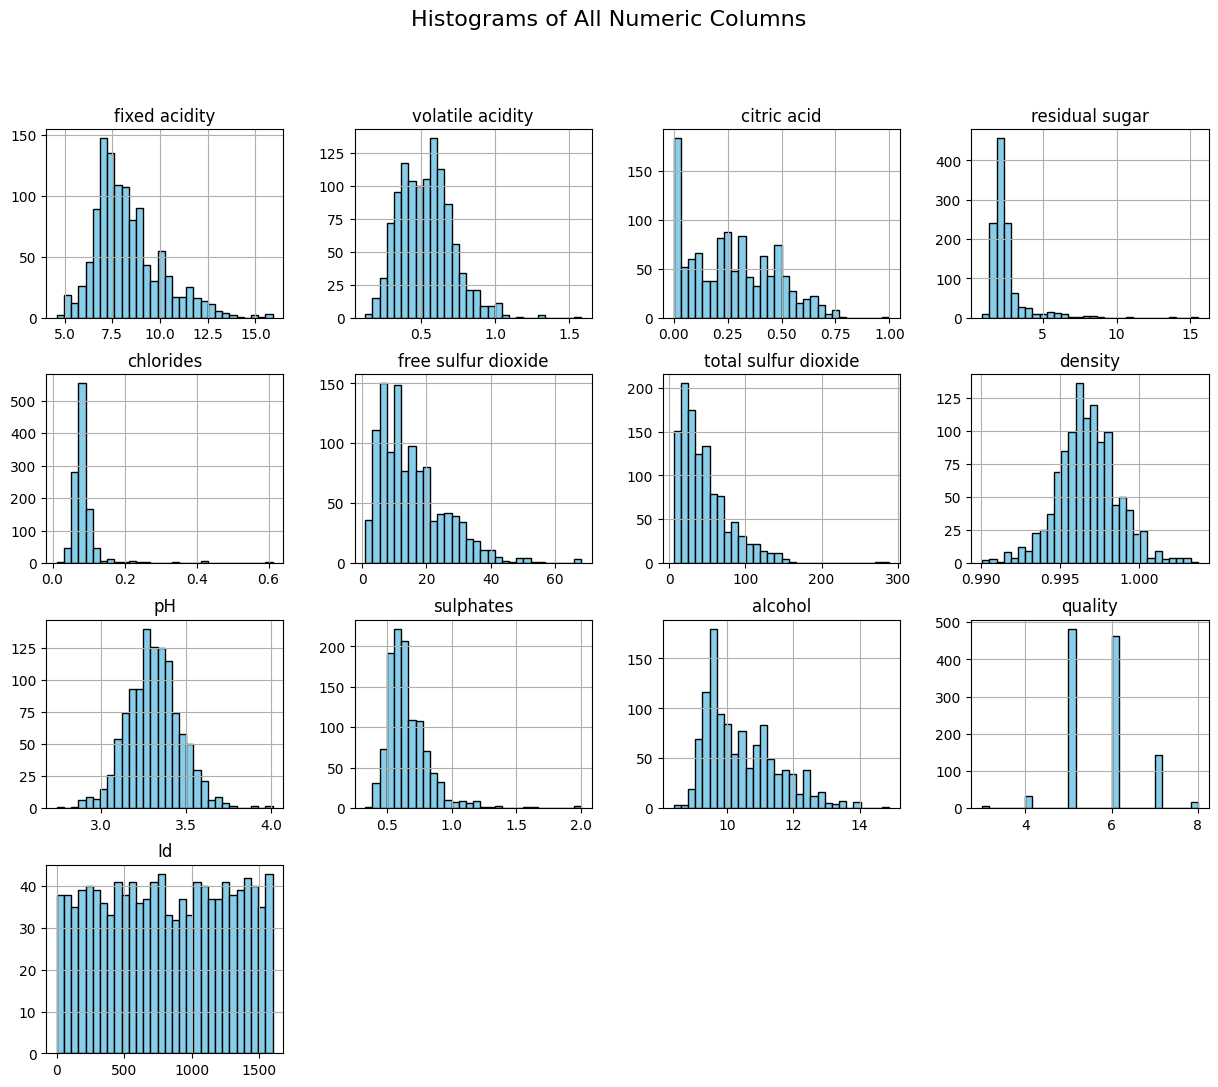

In [8]:
df.hist(figsize=(15, 12), bins=30, color='skyblue', edgecolor='black')
plt.suptitle('Histograms of All Numeric Columns', fontsize=16)
plt.show()

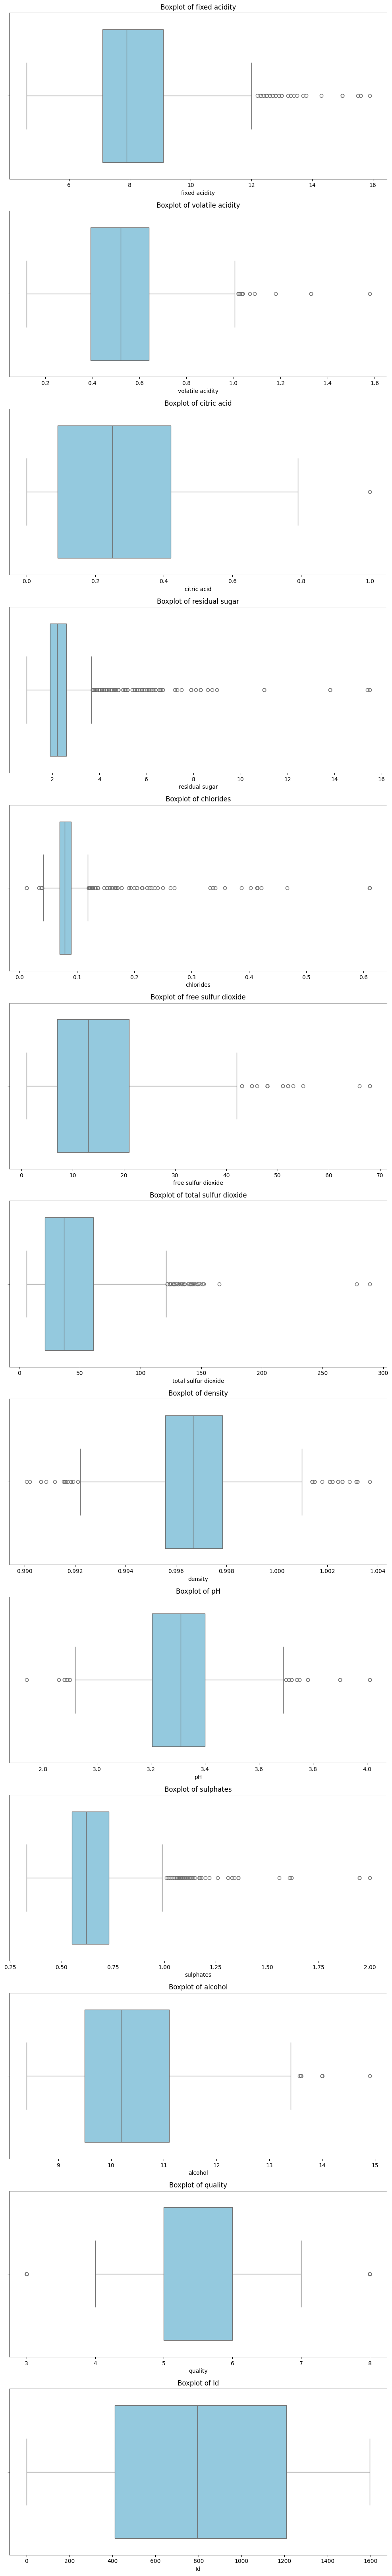

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(10, 5 * len(numeric_cols)))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

Removed outliers for better predictions

In [10]:
from scipy import stats
import numpy as np

df_no_outliers = df[(np.abs(stats.zscore(df.select_dtypes(include=[float, int]))) < 3).all(axis=1)]

print("Original shape:", df.shape)
print("After removing outliers:", df_no_outliers.shape)

Original shape: (1143, 13)
After removing outliers: (1041, 13)


Created a correlation plot to find the correction between the features and the target column


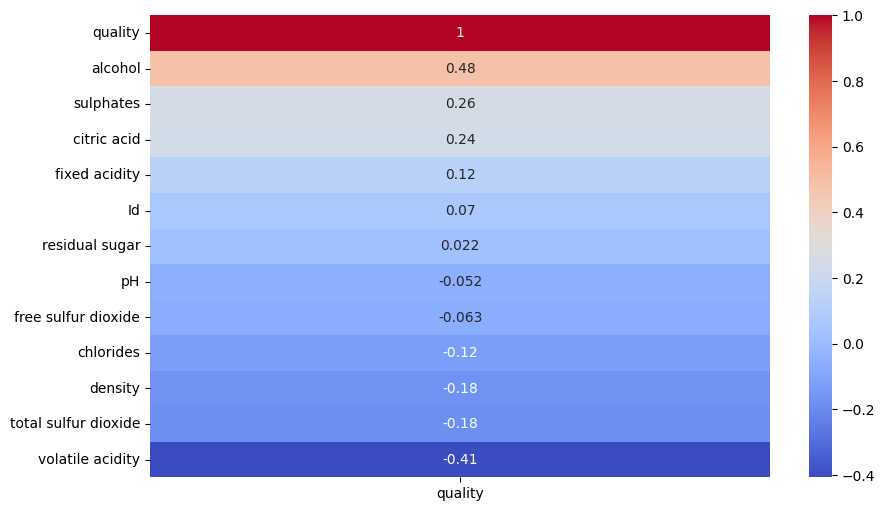

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr[['quality']].sort_values(by='quality', ascending=False), annot=True, cmap='coolwarm')
plt.show()


In [12]:
# Get correlation values with target 'quality'
corr_with_quality = corr['quality'].sort_values(ascending=False)

# Print feature names in that order (excluding 'quality' itself if you want only predictors)
features_sorted = corr_with_quality.index.tolist()

print("Features sorted by correlation with quality:")
for f in features_sorted:
    print(f)

Features sorted by correlation with quality:
quality
alcohol
sulphates
citric acid
fixed acidity
Id
residual sugar
pH
free sulfur dioxide
chlorides
density
total sulfur dioxide
volatile acidity


Dropped the unnecessary rows

In [13]:
df_no_outliers.drop("Id", axis=1,inplace=True)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18464\2621540349.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers.drop("Id", axis=1,inplace=True)


Defined the values of x and y

In [14]:
x = df_no_outliers.drop("quality", axis=1).values
y = df_no_outliers["quality"].values

In [15]:
x

array([[ 7.4  ,  0.7  ,  0.   , ...,  3.51 ,  0.56 ,  9.4  ],
       [ 7.8  ,  0.88 ,  0.   , ...,  3.2  ,  0.68 ,  9.8  ],
       [ 7.8  ,  0.76 ,  0.04 , ...,  3.26 ,  0.65 ,  9.8  ],
       ...,
       [ 6.2  ,  0.6  ,  0.08 , ...,  3.45 ,  0.58 , 10.5  ],
       [ 5.9  ,  0.55 ,  0.1  , ...,  3.52 ,  0.76 , 11.2  ],
       [ 5.9  ,  0.645,  0.12 , ...,  3.57 ,  0.71 , 10.2  ]],
      shape=(1041, 11))

Splitted the values for training and testing

In [16]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [17]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [18]:
print(x_train_scaled.shape)

(832, 11)


 Coded Ridge using normal equation

In [19]:
def ridge_regression(X, y, lam=0.0):
    n_features = X.shape[1]       # include bias
    I = np.eye(n_features)
    I[0, 0] = 0                    # do NOT regularize bias
    w = np.linalg.inv(X.T.dot(X) + lam * I).dot(X.T).dot(y)
    return w

In [20]:
# Add bias (intercept term)
X_train_b = np.c_[np.ones((x_train.shape[0], 1)), x_train]
X_test_b = np.c_[np.ones((x_test.shape[0], 1)), x_test]

# Test different λ values
lambdas = [0, 0.1, 1, 10]

for lam in lambdas:
    w = ridge_regression(X_train_b, y_train, lam)
    
    y_train_pred = X_train_b.dot(w)
    y_test_pred = X_test_b.dot(w)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    print(f"\nλ = {lam}")
    print("Train MSE:", round(train_mse, 3), " | Test MSE:", round(test_mse, 3))
    print("Train R²:", round(train_r2, 3), "   | Test R²:", round(test_r2, 3))



λ = 0
Train MSE: 0.372  | Test MSE: 0.381
Train R²: 0.406    | Test R²: 0.336

λ = 0.1
Train MSE: 0.372  | Test MSE: 0.379
Train R²: 0.405    | Test R²: 0.339

λ = 1
Train MSE: 0.373  | Test MSE: 0.38
Train R²: 0.405    | Test R²: 0.338

λ = 10
Train MSE: 0.381  | Test MSE: 0.385
Train R²: 0.391    | Test R²: 0.329


In [21]:
# Add bias (intercept term)
X_train_b = np.c_[np.ones((x_train_scaled.shape[0], 1)), x_train_scaled]
X_test_b = np.c_[np.ones((x_test_scaled.shape[0], 1)), x_test_scaled]

# Test different λ values
lambdas = [0, 0.1, 1, 10]

for lam in lambdas:
    w = ridge_regression(X_train_b, y_train, lam)
    
    y_train_pred = X_train_b.dot(w)
    y_test_pred = X_test_b.dot(w)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    print(f"\nλ = {lam}")
    print("Train MSE:", round(train_mse, 3), " | Test MSE:", round(test_mse, 3))
    print("Train R²:", round(train_r2, 3), "   | Test R²:", round(test_r2, 3))



λ = 0
Train MSE: 0.372  | Test MSE: 0.381
Train R²: 0.406    | Test R²: 0.336

λ = 0.1
Train MSE: 0.372  | Test MSE: 0.381
Train R²: 0.406    | Test R²: 0.336

λ = 1
Train MSE: 0.372  | Test MSE: 0.38
Train R²: 0.406    | Test R²: 0.337

λ = 10
Train MSE: 0.372  | Test MSE: 0.378
Train R²: 0.405    | Test R²: 0.341


In [22]:
rig_no = Ridge(alpha=10,max_iter=100)
rig_no.fit(x_train,y_train)
weights_noscale = rig_no.coef_
y_pred= rig_no.predict(x_test)
mse = mean_squared_error(y_test,y_pred)
r2= r2_score(y_test,y_pred)

In [23]:
print(r2)
print(mse)

0.328524854396294
0.38513629033115654


In [24]:
rig_le= Ridge(alpha=10,max_iter=100)
rig_le.fit(x_train_scaled,y_train)
weights_scale = rig_le.coef_
y_pred_scaled= rig_le.predict(x_test_scaled)
mses = mean_squared_error(y_test,y_pred_scaled)
r2s= r2_score(y_test,y_pred_scaled)
rmses = np.sqrt(mean_squared_error(y_test,y_pred_scaled))

In [25]:
print(r2s)
print(mses)
print(rmses)

0.34140731990524287
0.37774732737561056
0.6146115255798662


Visualization of Regularization Effect

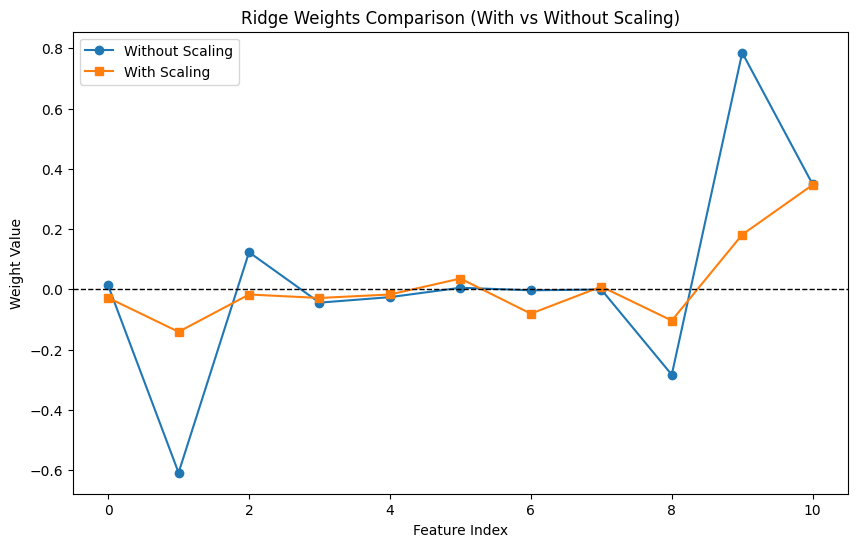

In [26]:
plt.figure(figsize=(10,6))
plt.plot(weights_noscale, "o-", label="Without Scaling")
plt.plot(weights_scale, "s-", label="With Scaling")
plt.axhline(0, color="black", linewidth=1, linestyle="--")
plt.title("Ridge Weights Comparison (With vs Without Scaling)")
plt.xlabel("Feature Index")
plt.ylabel("Weight Value")
plt.legend()
plt.show()

Weight Differences


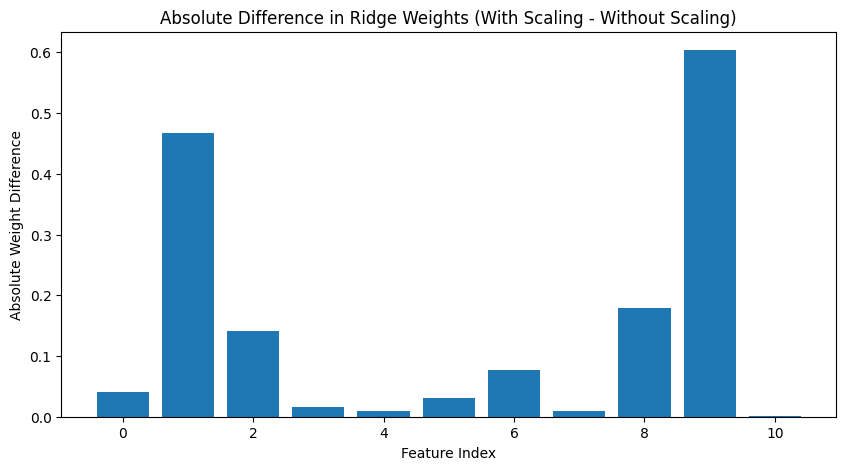

In [27]:
plt.figure(figsize=(10,5))
weight_diff = np.abs(weights_scale - weights_noscale)
plt.bar(range(len(weight_diff)), weight_diff)
plt.title("Absolute Difference in Ridge Weights (With Scaling - Without Scaling)")
plt.xlabel("Feature Index")
plt.ylabel("Absolute Weight Difference")
plt.show()

Part B: Cross-Validation for Model Selection


In [28]:
lambdas = np.logspace(-3, 3, 50)  # λ from 0.001 to 1000
coefs = []

In [29]:
for lam in lambdas:
    rig_v = Ridge(alpha=lam)
    rig_v.fit(x_train_scaled, y_train)  # using scaled features
    coefs.append(rig_v.coef_)
coefs = np.array(coefs)

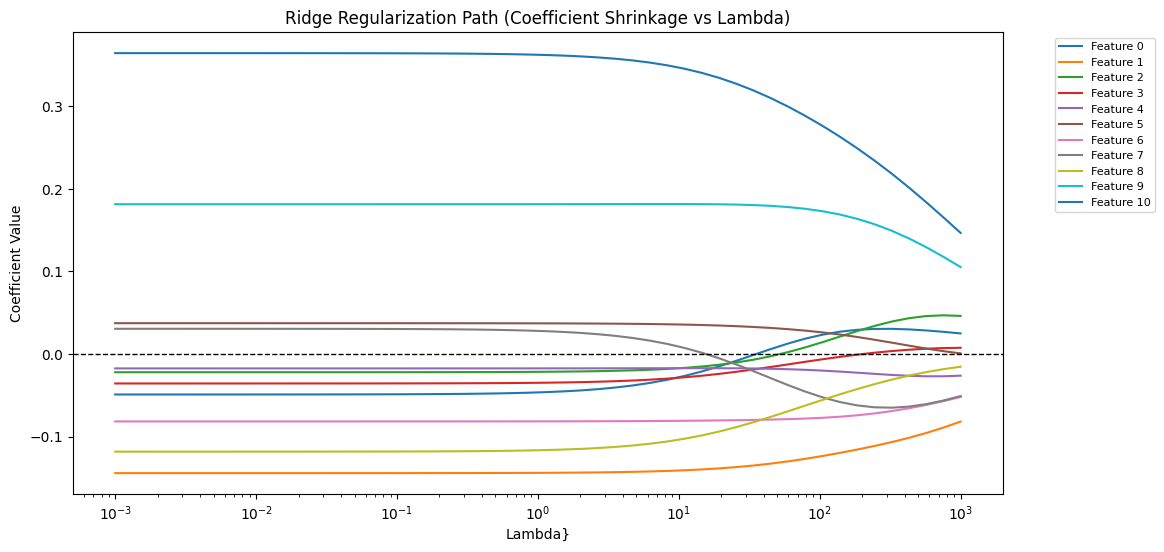

In [30]:
plt.figure(figsize=(12,6))
for i in range(coefs.shape[1]):
    plt.plot(lambdas, coefs[:, i], label=f"Feature {i}")
plt.xscale("log")
plt.xlabel("Lambda}")
plt.ylabel("Coefficient Value")
plt.title("Ridge Regularization Path (Coefficient Shrinkage vs Lambda)")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1, fontsize=8)
plt.show()

 Implement 5-Fold CV

In [31]:
from sklearn.utils import shuffle

# λ values to test
lambdas = np.arange(100)
k = 5  # number of folds

# Shuffle data first
X, y = shuffle(x_train_scaled, y_train, random_state=42)

n_samples = X.shape[0]
fold_size = n_samples // k

avg_val_rmse = []

for lam in lambdas:
    fold_rmse = []

    for i in range(k):
        # Define validation and training indices
        start, end = i * fold_size, (i + 1) * fold_size
        X_val, y_val = X[start:end], y[start:end]
        X_train_cv = np.vstack([X[:start], X[end:]])  # training folds
        y_train_cv = np.hstack([y[:start], y[end:]])

        # Add bias term
        X_train_cv_b = np.c_[np.ones(X_train_cv.shape[0]), X_train_cv]
        X_val_b = np.c_[np.ones(X_val.shape[0]), X_val]

        # Fit Ridge Regression
        w = ridge_regression(X_train_cv_b, y_train_cv, lam)

        # Predict on validation fold
        y_val_pred = X_val_b.dot(w)

        # Compute RMSE for this fold
        fold_rmse.append(np.sqrt(mean_squared_error(y_val, y_val_pred)))

    # Average RMSE across folds
    avg_rmse = np.mean(fold_rmse)
    avg_val_rmse.append(avg_rmse)
    print(f"λ = {lam} | Average Validation RMSE: {avg_rmse:.4f}")

# Optional: Find λ with minimum validation RMSE
best_lambda = lambdas[np.argmin(avg_val_rmse)]
print(f"\nBest λ from 5-Fold CV: {best_lambda}")


λ = 0 | Average Validation RMSE: 0.6210
λ = 1 | Average Validation RMSE: 0.6209
λ = 2 | Average Validation RMSE: 0.6209
λ = 3 | Average Validation RMSE: 0.6208
λ = 4 | Average Validation RMSE: 0.6207
λ = 5 | Average Validation RMSE: 0.6207
λ = 6 | Average Validation RMSE: 0.6206
λ = 7 | Average Validation RMSE: 0.6205
λ = 8 | Average Validation RMSE: 0.6205
λ = 9 | Average Validation RMSE: 0.6204
λ = 10 | Average Validation RMSE: 0.6204
λ = 11 | Average Validation RMSE: 0.6204
λ = 12 | Average Validation RMSE: 0.6203
λ = 13 | Average Validation RMSE: 0.6203
λ = 14 | Average Validation RMSE: 0.6202
λ = 15 | Average Validation RMSE: 0.6202
λ = 16 | Average Validation RMSE: 0.6202
λ = 17 | Average Validation RMSE: 0.6202
λ = 18 | Average Validation RMSE: 0.6201
λ = 19 | Average Validation RMSE: 0.6201
λ = 20 | Average Validation RMSE: 0.6201
λ = 21 | Average Validation RMSE: 0.6201
λ = 22 | Average Validation RMSE: 0.6200
λ = 23 | Average Validation RMSE: 0.6200
λ = 24 | Average Validatio

Find Optimal λ

Plot validation error vs λ

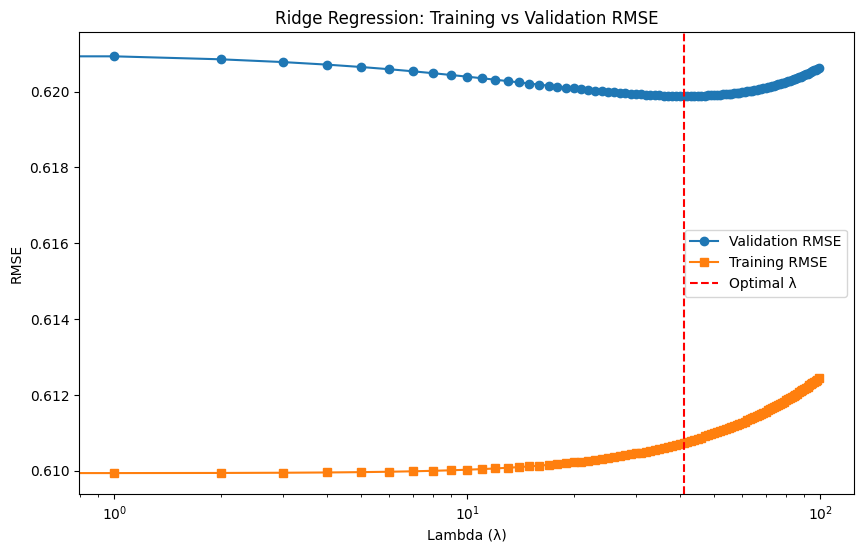

Optimal λ from CV: 41


In [32]:
# --- Compute training RMSE for each lambda (on full training set) ---
train_rmse_all = []

for lam in lambdas:
    # Add bias term
    X_train_b = np.c_[np.ones(x_train_scaled.shape[0]), x_train_scaled]
    
    # Fit Ridge
    w = ridge_regression(X_train_b, y_train, lam)
    
    # Predict on training data
    y_train_pred = X_train_b.dot(w)
    train_rmse_all.append(np.sqrt(mean_squared_error(y_train, y_train_pred)))

# --- Plot Validation vs Training RMSE ---
plt.figure(figsize=(10,6))
plt.plot(lambdas, avg_val_rmse, "o-", label="Validation RMSE")
plt.plot(lambdas, train_rmse_all, "s-", label="Training RMSE")
plt.xscale("log")
plt.xlabel("Lambda (λ)")
plt.ylabel("RMSE")
plt.title("Ridge Regression: Training vs Validation RMSE")
plt.axvline(lambdas[np.argmin(avg_val_rmse)], color="red", linestyle="--", label="Optimal λ")
plt.legend()
plt.show()

# --- Identify best λ ---
best_lambda = lambdas[np.argmin(avg_val_rmse)]
print(f"Optimal λ from CV: {best_lambda}")


# Part-C

Compare Models

Final Model Comparison

In [33]:
lr= LinearRegression()
lr.fit(x_train_scaled,y_train)
y_lr_pred = lr.predict(x_test_scaled)
r2lr = r2_score(y_test,y_lr_pred)
mselr = mean_squared_error(y_test,y_lr_pred)
rmselr = np.sqrt( mean_squared_error(y_test,y_lr_pred))

In [34]:
print("r2lr",r2lr)
print("mselr",mselr)
print("rmselr",rmselr)

r2lr 0.33619852410328765
mselr 0.3807349231271315
rmselr 0.6170372137295541


In [35]:
rig = Ridge(alpha=best_lambda)
rig.fit(x_train_scaled, y_train)
weights_scale = rig.coef_
y_pred_scaled= rig.predict(x_test_scaled)
mses = mean_squared_error(y_test,y_pred_scaled)
r2s= r2_score(y_test,y_pred_scaled)
rmses = np.sqrt(mean_squared_error(y_test,y_pred_scaled))

In [36]:
print(r2s)
print(mses)
print(rmses)
print(weights_scale)

0.3507760799519314
0.37237371151952364
0.6102243124618386
[ 0.00376895 -0.13337573 -0.00406597 -0.01662241 -0.01767217  0.03203719
 -0.0794349  -0.02640927 -0.07813634  0.1797549   0.31293813]


In [37]:
rig_l= Ridge(alpha=1000,max_iter=1000)
rig_l.fit(x_train_scaled,y_train)
weights_scale = rig_l.coef_
y_pred_scaled= rig_l.predict(x_test_scaled)
mses = mean_squared_error(y_test,y_pred_scaled)
r2s= r2_score(y_test,y_pred_scaled)
rmses = np.sqrt(mean_squared_error(y_test,y_pred_scaled))

In [38]:
print(r2s)
print(mses)
print(rmses)

0.3310144041198615
0.3837083656322197
0.6194419792298709


Feature Importance Analysis


Feature Importance (Ridge, optimal λ):

                 Feature  Coefficient  Abs_Coefficient
10               alcohol     0.312938         0.312938
9              sulphates     0.179755         0.179755
1       volatile acidity    -0.133376         0.133376
6   total sulfur dioxide    -0.079435         0.079435
8                     pH    -0.078136         0.078136
5    free sulfur dioxide     0.032037         0.032037
7                density    -0.026409         0.026409
4              chlorides    -0.017672         0.017672
3         residual sugar    -0.016622         0.016622
2            citric acid    -0.004066         0.004066
0          fixed acidity     0.003769         0.003769


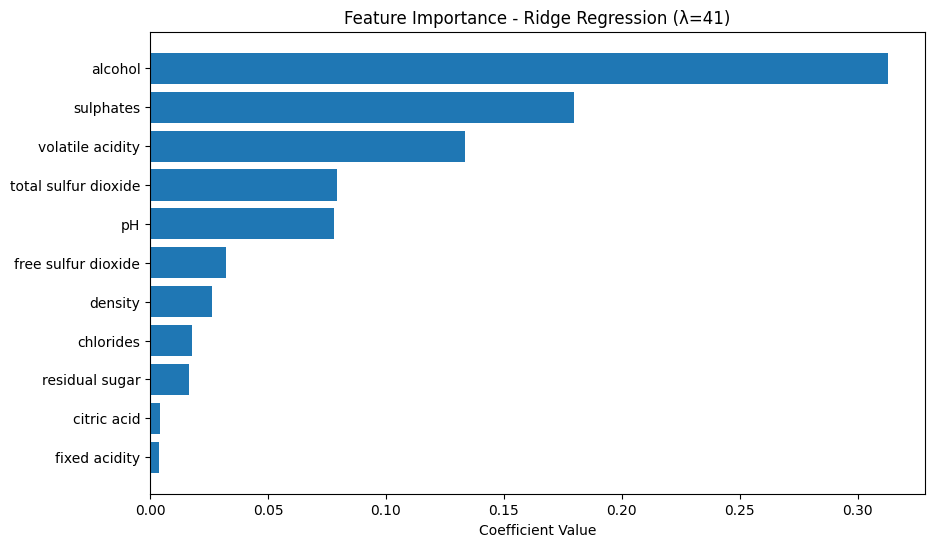

In [39]:
features = df_no_outliers.drop("quality", axis=1).columns  # 11 feature names
coef_opt = rig.coef_  # now length = 11 (correct)

feature_importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": coef_opt,
    "Abs_Coefficient": np.abs(coef_opt)
}).sort_values("Abs_Coefficient", ascending=False)

print("\nFeature Importance (Ridge, optimal λ):\n")
print(feature_importance)

# Plot
plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"], feature_importance["Abs_Coefficient"])
plt.xlabel("Coefficient Value")
plt.title(f"Feature Importance - Ridge Regression (λ={best_lambda})")
plt.gca().invert_yaxis()
plt.show()


In [40]:
# Example new wine sample (replace with real values)
new_data = {
    'fixed acidity': [7.4],
    'volatile acidity': [0.7],
    'citric acid': [0.0],
    'residual sugar': [1.9],
    'chlorides': [0.076],
    'free sulfur dioxide': [11.0],
    'total sulfur dioxide': [34.0],
    'density': [0.9978],
    'pH': [3.51],
    'sulphates': [0.56],
    'alcohol': [9.4]
}

new_df = pd.DataFrame(new_data)

# Scale using the SAME scaler used for training
new_scaled = scaler.transform(new_df)

# Predict quality
prediction = rig.predict(new_scaled)
print("Predicted Wine Quality:", prediction[0])


Predicted Wine Quality: 5.017297008802412


C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [41]:
new_data = {
    'fixed acidity': [6.8],
    'volatile acidity': [0.42],
    'citric acid': [0.33],
    'residual sugar': [2.4],
    'chlorides': [0.058],
    'free sulfur dioxide': [20.0],
    'total sulfur dioxide': [85.0],
    'density': [0.9964],
    'pH': [3.28],
    'sulphates': [0.72],
    'alcohol': [11.6]
}

new_df = pd.DataFrame(new_data)

new_scaled = scaler.transform(new_df)
prediction = rig.predict(new_scaled)
print("Predicted Wine Quality:", prediction[0])


Predicted Wine Quality: 6.170814097284011


C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
